In [9]:
# Core scientific stack
import numpy as np
import pandas as pd

# Scikit‑learn utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Visualization (optional but helpful)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
import os
import pandas as pd

# Option 1: Check what files are available in current directory
print("Current working directory:", os.getcwd())
print("Files in directory:", os.listdir())

# Option 2: Try to load your actual data file (REPLACE THIS WITH YOUR FILENAME)
# Common approaches:
# - If file is in same folder: df = pd.read_csv('actual_filename.csv')
# - If file is elsewhere: df = pd.read_csv('/full/path/to/your_file.csv')
# - If uploading in Colab: use files.upload() (see commented code below)

# UNCOMMENT AND EDIT ONE OF THESE BASED ON YOUR SITUATION:

# A) If your CSV is in the current directory (most common):
# df = pd.read_csv('your_real_file.csv')  # <-- REPLACE 'your_real_file.csv' with actual name

# B) If you know the full path:
# df = pd.read_csv(r'C:\Users\YourName\Documents\your_data.csv')  # Windows
# df = pd.read_csv('/home/yourname/data/your_data.csv')          # Linux/Mac

# C) If using Google Colab and need to upload:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])  # Gets first uploaded file

# D) FALLBACK: Create sample data if no file found (for testing the pipeline)
try:
    # Try to load a file named 'data.csv' (you can change this)
    df = pd.read_csv('data.csv')
    print("\n✅ Loaded 'data.csv' successfully")
except FileNotFoundError:
    print("\n⚠️  'data.csv' not found. Creating sample dataset for demonstration...")
    # Create a simple text classification dataset
    data = {
        'text': [
            'I love this product', 'Great service and fast delivery', 'Worst experience ever',
            'Not worth the money', 'Awesome quality', 'Terrible support', 
            'Happy with my purchase', 'Will not buy again', 'Highly recommend', 
            'Very disappointed', 'Excellent value for money', 'Poor customer service',
            'Best purchase I made', 'Below average quality', 'Fantastic experience'
        ],
        'label': ['positive', 'positive', 'negative', 'negative', 'positive', 
                 'negative', 'positive', 'negative', 'positive', 'negative',
                 'positive', 'negative', 'positive', 'negative', 'positive']
    }
    df = pd.DataFrame(data)
    print("📝 Sample dataset created with", len(df), "rows")

# Show what we loaded
print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Current working directory: C:\Users\anas1
Files in directory: ['-1.14-windows.xml', '.amr', '.anaconda', '.android', '.antigravity-ide', '.cache', '.claude', '.claude.json', '.conda', '.config', '.continuum', '.copilot', '.gemini', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.ssh', '.vscode', '.vscode-shared', '.wsa-pacman', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'DL TASK-6.ipynb', 'Documents', 'Downloads', 'Favorites', 'Games', 'IntelGraphicsProfiles', 'knn_text_classifier.pkl', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NLP TASK-10.ipynb', 'NLP TASK-10pynb', 'NLP TASK-11.ipynb', 'NLP TASK-9.ipynb', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{1861afa4-b801-11ef-af8e-eda0e3e6c354}.TM.blf', 'NTUSER.DAT{1861afa4-b801-11ef-af8e-eda0e3e6c354}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{1861afa4-b801-11ef-af8e-eda0e3e6c354}.TMContainer00000000000000000002.regtrans-ms', 'ntus

,text,label
0,I love this product,positive
1,Great service and fast delivery,positive
2,Worst experience ever,negative
3,Not worth the money,negative
4,Awesome quality,positive


In [11]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK resources if not already present
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def custom_cleaner(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize by whitespace
    tokens = text.split()
    # Remove stopwords and stem
    tokens = [stemmer.stem(tok) for tok in tokens if tok not in stop_words]
    return " ".join(tokens)

# Apply cleaning
df['clean_text'] = df['text'].apply(custom_cleaner)
df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anas1\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,text,label,clean_text
0,I love this product,positive,love product
1,Great service and fast delivery,positive,great servic fast deliveri
2,Worst experience ever,negative,worst experi ever
3,Not worth the money,negative,worth money
4,Awesome quality,positive,awesom qualiti


In [12]:
X = df['clean_text']          # features (raw text after cleaning)
y = df['label']               # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:",  X_test.shape[0])

Train size: 12
Test size: 3


In [13]:
# Create pipeline
knn_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2),        # unigrams + bigrams often help
        max_features=5000,        # limit dimensionality for k‑NN
        sublinear_tf=True)),
    ('knn', KNeighborsClassifier(
        n_neighbors=5,            # will be tuned later
        metric='cosine',          # cosine works well with TF‑IDF
        weights='distance'))      # closer neighbors vote more
])

# Fit on training data
knn_pipe.fit(X_train, y_train)

# Predict on test set
y_pred = knn_pipe.predict(X_test)

# Basic evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
    positive       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



C:\ANACONDA\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ANACONDA\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ANACONDA\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
param_grid = {
    'tfidf__max_features': [3000, 5000, 8000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__metric': ['cosine', 'euclidean']
}

grid = GridSearchCV(
    knn_pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross‑validated accuracy:", grid.best_score_)

# Evaluate the best model on the held‑out test set
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print("\nTest set accuracy with best model:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (best model):\n", classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'knn__metric': 'cosine', 'knn__n_neighbors': 9, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
Best cross‑validated accuracy: 0.6

Test set accuracy with best model: 0.3333333333333333

Classification Report (best model):
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
    positive       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



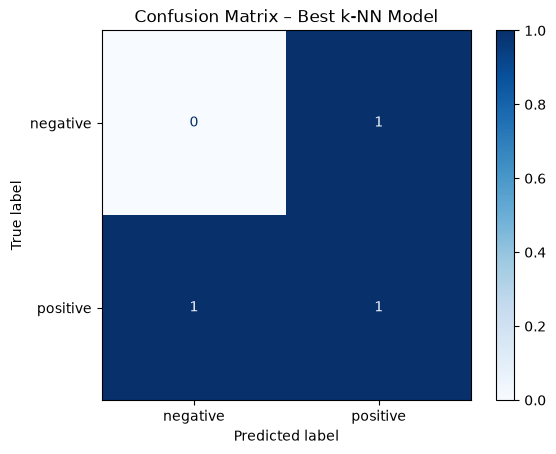

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix – Best k‑NN Model')
plt.show()